In [15]:
from nilearn import plotting 

plotting.view_img('/Users/zach/2025_RA/matthias/final images/tmaps/wake_tmap_group.nii.gz', threshold=1)

KeyboardInterrupt: 

In [2]:
from mreyemove.analysis.glm.cli import construct_desc
from mreyemove.analysis.glm.config import GLMConfig
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    exclude_subjects=["01", "07", "09", "12"],
    tr=2.1,
    task="sleep",
    load_signal=False,
    load_eog=False,
    desc_add="clean-with-fd-clamped",
)
config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/eog_sleep.yml")
desc_add = construct_desc(dataset=mrio, config=config)

desc_add = f"{desc_add}-{config.second_level.method}"

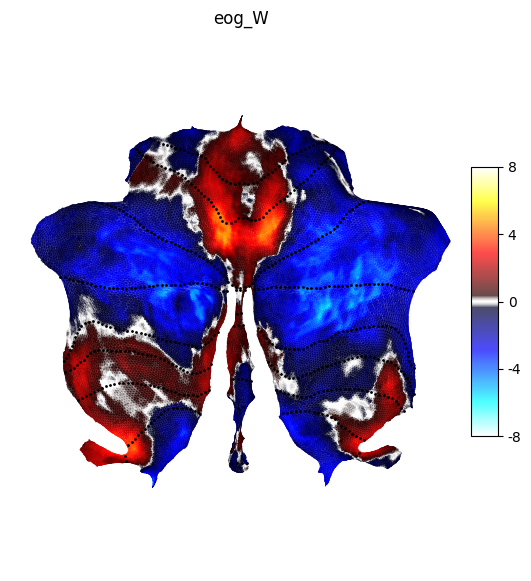

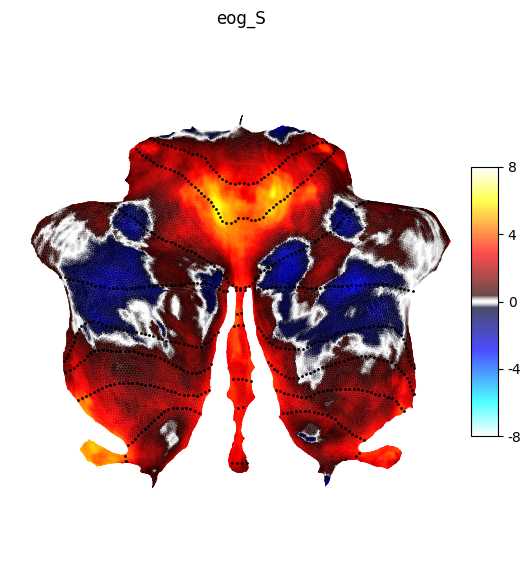

In [3]:
from pathlib import Path
from mreyemove.plotting.glm import custom_cmap
from nilearn import image
# Import necessary packages
from nilearn import plotting
import nibabel as nib
from SUITPy import flatmap
import SUITPy as suit
config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/eog_sleep.yml")
desc_add = construct_desc(dataset=mrio, config=config)

desc_add = f"{desc_add}-{config.second_level.method}"
output_dir = Path('/Users/zach/2025_RA/matthias/final images/group_level/cerebellum/eog/') 
output_dir.mkdir(parents=True, exist_ok=True)

for state in ("W", "S"):
    contrast = f"eog_{state}"
    output_path = output_dir / f"{contrast}.png"
    if config.second_level.method == "flame":
        data, _ = mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)
        funcdata = flatmap.vol_to_surf(data.t_stat, space='FSL')
    elif config.second_level.method == "randomise":
        data, _ = mrio.load_randomise_result(contrast=contrast, desc_add=desc_add)
        funcdata = flatmap.vol_to_surf(data.t_stat_neg, space='FSL')
    ax = flatmap.plot(data=funcdata, cmap=custom_cmap(), 
        new_figure=True, 
        colorbar=True, 
        render='matplotlib',
        cscale=[-8, 8],)
    ax.set_title(contrast)
    ax.figure.savefig(output_path, format="png", dpi=300, bbox_inches="tight")

/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_15817/3217867201.py:4: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  plotting.view_img(data.t_stat, cmap=custom_cmap(), threshold=1, symmetric_cmap=True, width_view=1000)



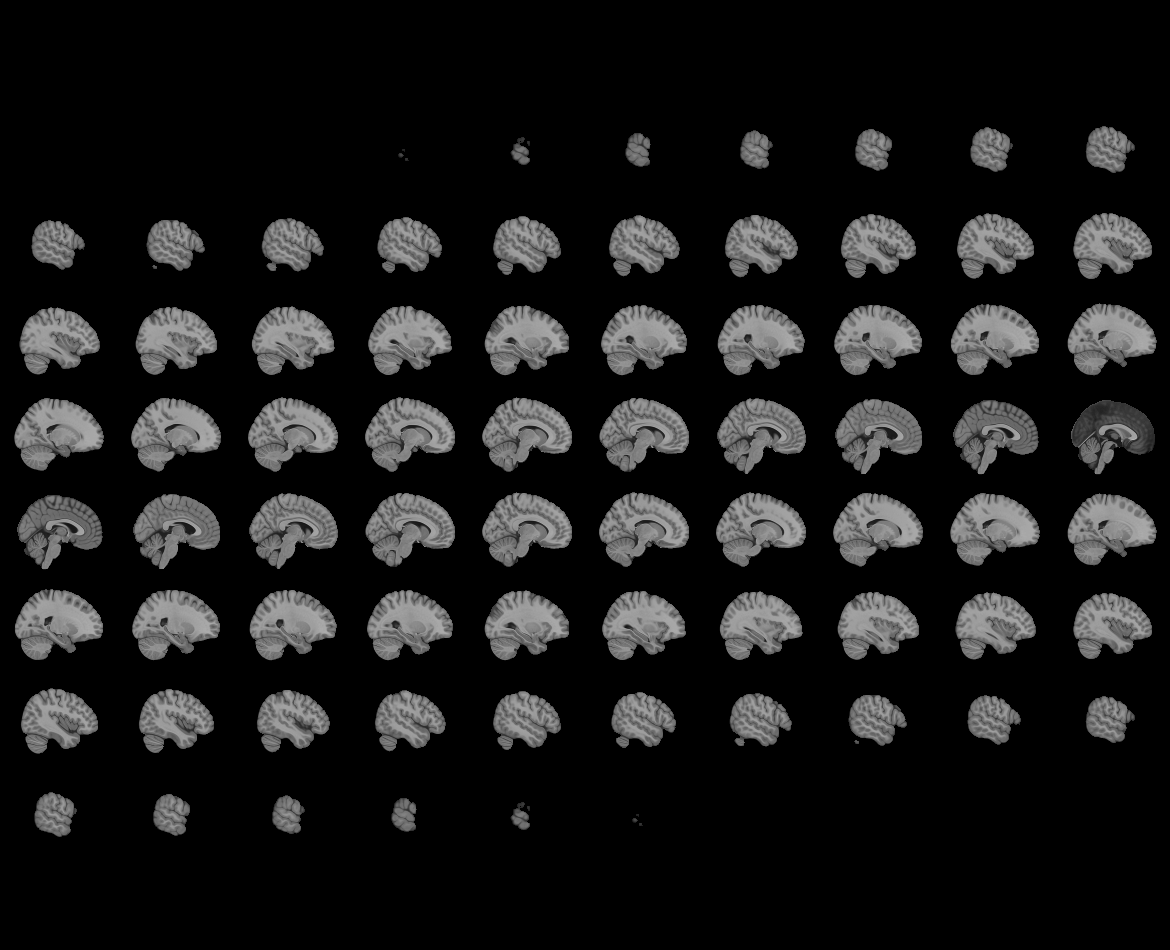
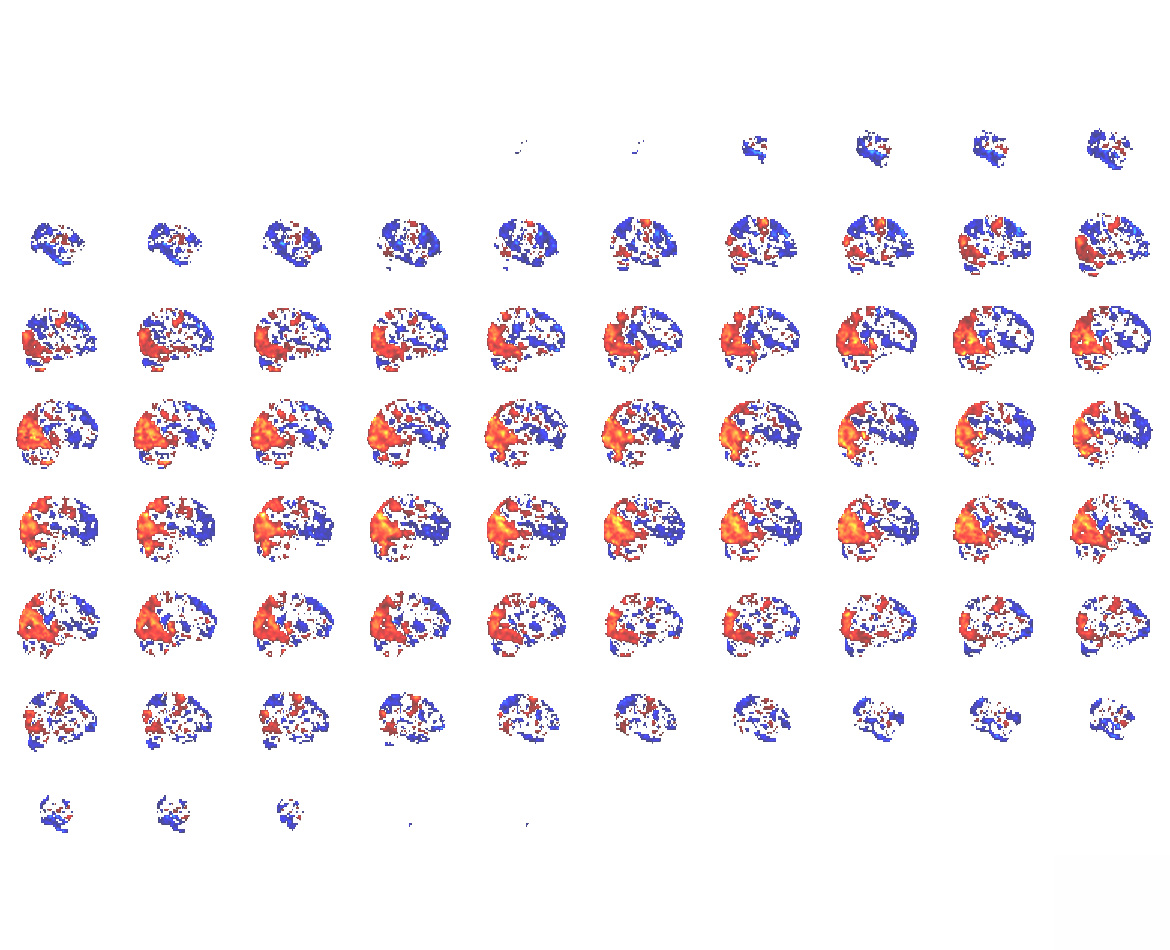

In [28]:
from nilearn import plotting 
contrast = "mreyemove_W"
data, _ = mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)
plotting.view_img(data.t_stat, cmap=custom_cmap(), threshold=1, symmetric_cmap=True, width_view=1000)
# funcdata = flatmap.vol_to_surf(data.t_stat, space='FSL')
# 
# flatmap.plot(data=funcdata, cmap=custom_cmap(), 
#     new_figure=True, 
#     colorbar=True, 
#     render='matplotlib',
#              cscale=[-7, 7])

/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_15817/2465599252.py:4: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  plotting.view_img(data.t_stat, cmap=custom_cmap(), threshold=1, symmetric_cmap=True, width_view=1000)



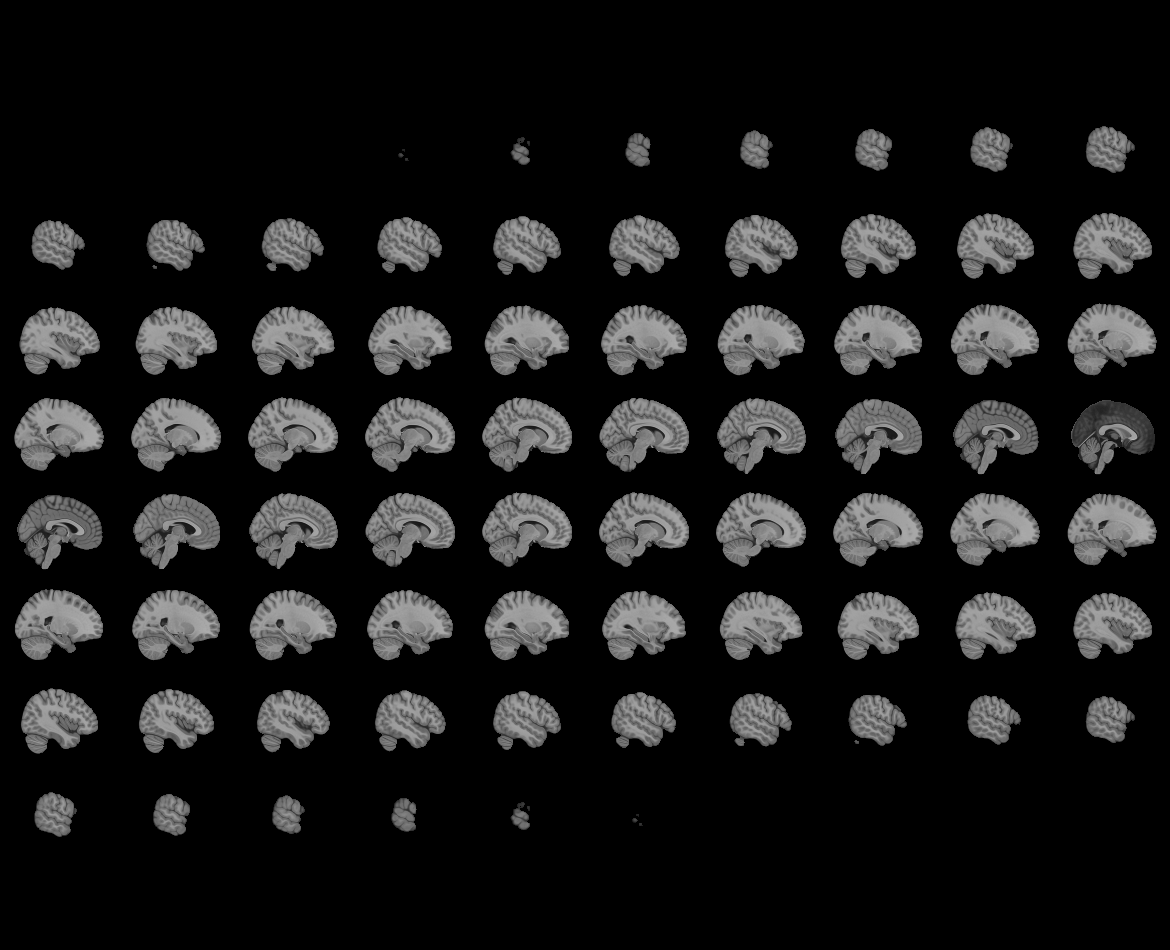
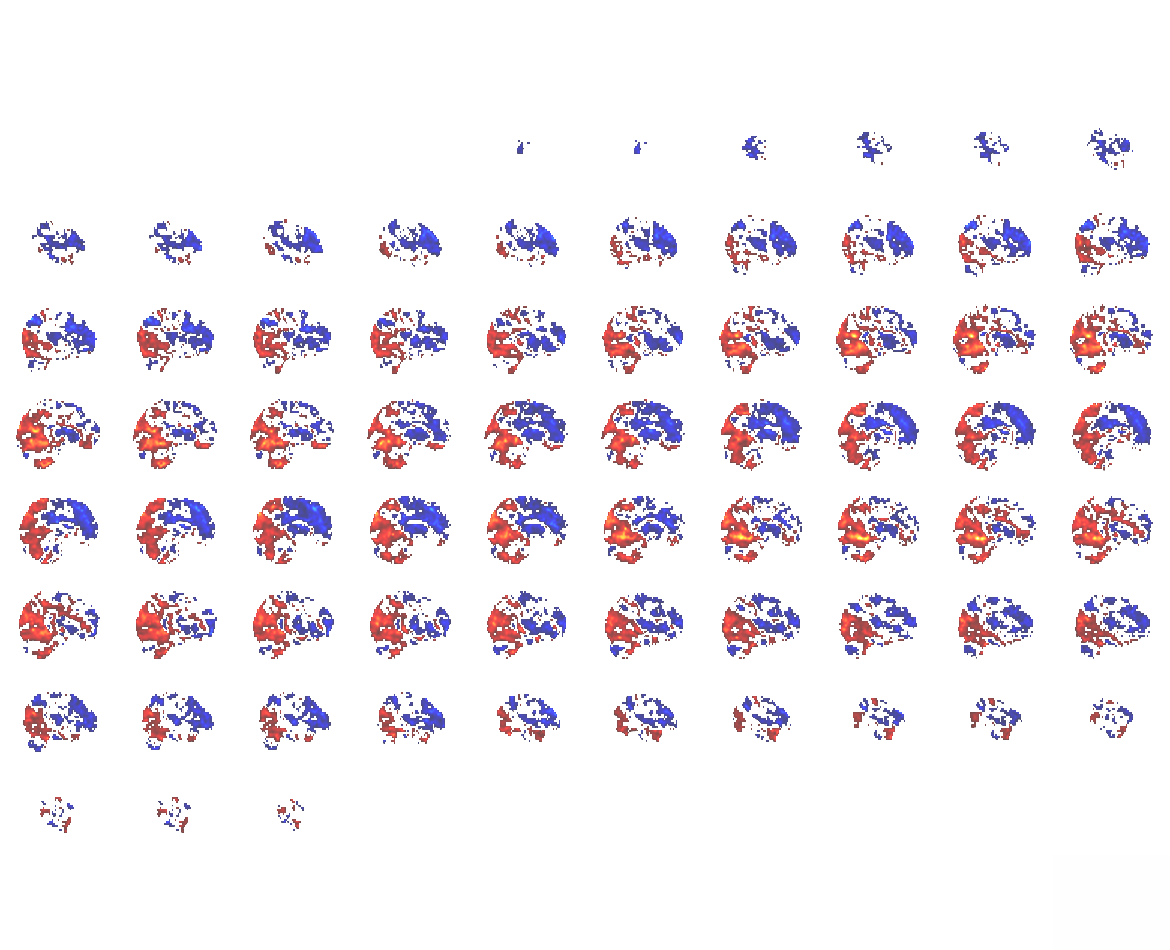

In [29]:
from nilearn import plotting 
contrast = "mreyemove_S"
data, _ = mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)
plotting.view_img(data.t_stat, cmap=custom_cmap(), threshold=1, symmetric_cmap=True, width_view=1000)
# funcdata = flatmap.vol_to_surf(data.t_stat, space='FSL')
# 
# flatmap.plot(data=funcdata, cmap=custom_cmap(), 
#     new_figure=True, 
#     colorbar=True, 
#     render='matplotlib',
#              cscale=[-7, 7])

In [3]:

from pathlib import Path
from scipy.stats import spearmanr
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
from tqdm.auto import trange
import numpy as np
import gdist
from nilearn.surface import load_surf_mesh, vol_to_surf, load_surf_data
from nilearn import datasets, plotting
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from mreyemove.plotting.glm import custom_cmap
from nilearn.plotting.surface._matplotlib_backend import (
    _plot_surf,
    _get_ticks,
    _colorbar_from_array,
)
from nilearn.plotting.surface._utils import check_surface_plotting_inputs


def geodesic_neighborhoods(coords, faces, radius_mm=9.0, chunk_size=500):
    """
    Approximate geodesic neighborhoods using Dijkstra shortest paths
    on the mesh edge graph (Chen et al., 2011).
    Returns an array of shape (n,) where each entry i is an array 
    of indices less than radius_mm away from vertex i in the graph 
    """
    n = len(coords)
    # faces = faces.astype(np.int32)

    # Build weighted adjacency graph from mesh edges (vectorized)
    
    # Extract triangle vertices (from faces) to construct a list of pairwise edges
    edges = np.vstack([faces[:, [0, 1]], faces[:, [1, 2]], faces[:, [0, 2]]])
    
    # Compute norm (magnitude) of distance between edges
    dists = np.linalg.norm(coords[edges[:, 0]] - coords[edges[:, 1]], axis=1)
    
    # Construct graph, edges in both directions
    graph = csr_matrix(
        (np.concatenate([dists, dists]),
         (np.concatenate([edges[:, 0], edges[:, 1]]),
          np.concatenate([edges[:, 1], edges[:, 0]]))),
        shape=(n, n),
    )

    # Chunked Dijkstra with distance cutoff
    neighborhoods = [None] * n
    for start in trange(0, n, chunk_size, desc="Dijkstra neighborhoods"):
        end = min(start + chunk_size, n)
        dist_chunk = dijkstra(
            graph, directed=False,
            indices=np.arange(start, end),
            limit=radius_mm,
        )
        for local_i in range(end - start):
            # Collect indices where distances are not None (and therefore lower than radius_mm)
            neighborhoods[start + local_i] = np.where(np.isfinite(dist_chunk[local_i]))[0]

    return neighborhoods


def surface_searchlight_correlation(
    map_a_surf: np.ndarray,
    map_b_surf: np.ndarray,
    coords: np.ndarray,
    faces: np.ndarray,
    radius_mm: float = 10.0,
    min_vertices: int = 10,
) -> np.ndarray:
    """
    Compute searchlight Pearson correlation between two surface maps
    using geodesic neighborhoods (Dijkstra on mesh graph).
    """
    print(f"Building geodesic neighborhoods (radius={radius_mm}mm)...")
    neighborhoods = geodesic_neighborhoods(coords, faces, radius_mm=radius_mm)

    neighbor_counts = np.array([len(n) for n in neighborhoods])
    print(f"Neighbors — Mean: {neighbor_counts.mean():.0f}, "
          f"Median: {np.median(neighbor_counts):.0f}, "
          f"Min: {neighbor_counts.min()}, Max: {neighbor_counts.max()}")

    corr_map = np.zeros(len(coords), dtype=np.float32)
    for i, nbrs in enumerate(neighborhoods):
        if len(nbrs) < min_vertices:
            continue
        a = map_a_surf[nbrs]
        b = map_b_surf[nbrs]
        if a.std() == 0 or b.std() == 0:
            continue
        corr_map[i] = spearmanr(a, b).statistic
    return corr_map



/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/SUITPy/surfaces/PIAL_FSL.surf.gii
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/SUITPy/surfaces/WHITE_FSL.surf.gii
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/SUITPy/surfaces/PIAL_FSL.surf.gii
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/SUITPy/surfaces/WHITE_FSL.surf.gii
Building geodesic neighborhoods (radius=38.0mm)...


Dijkstra neighborhoods:   0%|          | 0/58 [00:00<?, ?it/s]

Neighbors — Mean: 1389, Median: 1426, Min: 1, Max: 2326


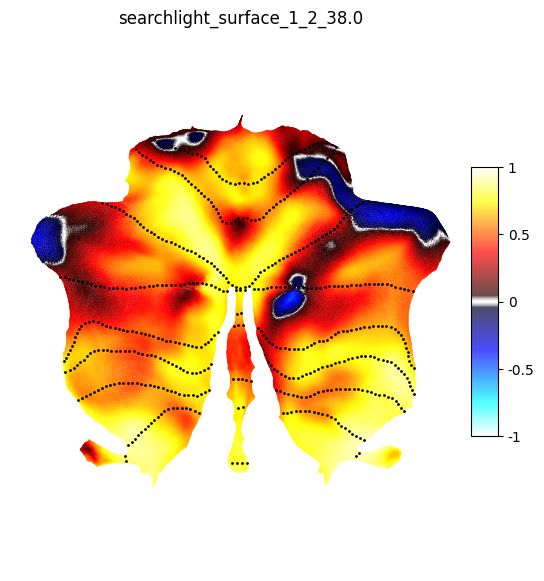

In [11]:

from mreyemove.analysis.glm.cli import construct_desc
import os
import nibabel as nib 
from SUITPy import flatmap

config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/original.yml")
desc_add = construct_desc(dataset=mrio, config=config)
output_dir = Path('/Users/zach/2025_RA/matthias/final images/group_level/cerebellum/')

state_1 = "1"
state_2 = "2"
radius_mm = 38.0
title = f"searchlight_surface_{state_1}_{state_2}_{radius_mm}"
surf_path = os.path.join(flatmap._base_dir,'surfaces', f'PIAL_FSL.surf.gii')
coords, faces = load_surf_mesh(surf_path)

vol_a,_ = mrio.load_FLAME_result(contrast=f"mreyemove_{state_1}", desc_add=desc_add)
vol_b,_ = mrio.load_FLAME_result(contrast=f"mreyemove_{state_2}", desc_add=desc_add)


surf_a = flatmap.vol_to_surf(vol_a.t_stat, space='FSL')
surf_b = flatmap.vol_to_surf(vol_b.t_stat, space='FSL')

results = surface_searchlight_correlation(
    map_a_surf=surf_a,
    map_b_surf=surf_b,
    coords=coords,
    faces=faces,
    radius_mm=radius_mm,
    min_vertices=10,
)

ax = flatmap.plot(data=results, cmap=custom_cmap(), 
        new_figure=True, 
        colorbar=True, 
        render='matplotlib',
        cscale=[-1.0, 1.0])
ax.set_title(title)

output_path = output_dir / f"{title}.png"

ax.figure.savefig(output_path, format="png", dpi=300, bbox_inches="tight")


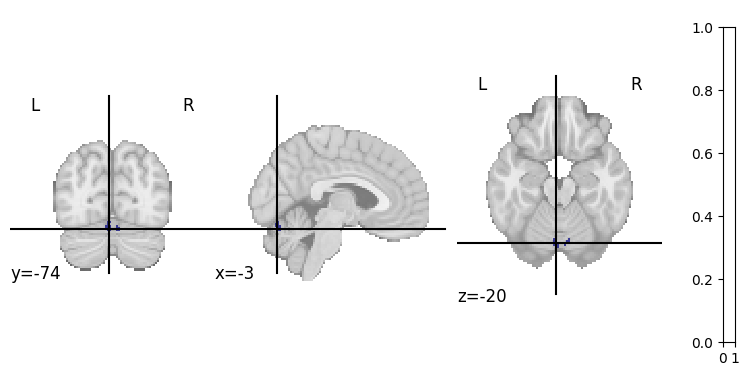

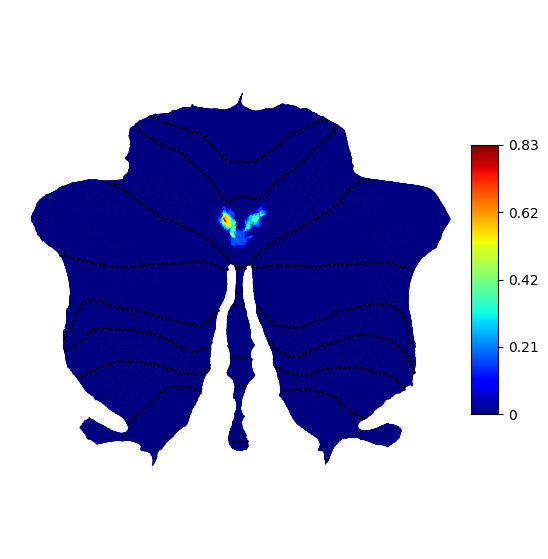

In [6]:
from matplotlib.patches import Patch
from matplotlib.colors import to_rgb
from matplotlib.colors import ListedColormap
from pathlib import Path
from mreyemove.plotting.glm import custom_cmap
from nilearn import image
# Import necessary packages
from nilearn import plotting
import nibabel as nib
from SUITPy import flatmap
import SUITPy as suit
from mreyemove.analysis.glm.atlas import fetch_atlas

atlas = fetch_atlas("cel_ret")

ROIS_TO_PLOT = {
    "OMV": [ "left_mOMV", "right_mOMV"] #, "left_lOMV",  "right_lOMV" ],
    # "VIIb": [ "left_VIIb", "right_VIIb" ],
    # "VIIIb": [ "left_mVIIIb", "left_lVIIIb", "right_mVIIIb", "right_lVIIIb" ],
}

atlas_data = atlas.maps.get_fdata()
combined = np.zeros(atlas_data.shape, dtype=np.int32)
roi_to_idx = {roi: i for i, roi in enumerate(atlas.labels, start=1)}

for plot_idx, plot_name in enumerate(ROIS_TO_PLOT, start=1):
  roi_ids = [roi_to_idx[roi_name] for roi_name in ROIS_TO_PLOT[plot_name]]
  combined[np.isin(atlas_data, roi_ids)] = plot_idx

combined_img = image.new_img_like(atlas.maps, combined, copy_header=True)


# colors = ["lightgray", "blue", "red", "yellow", "orange"]
# alpha = 1
# rgba_colors = [(*to_rgb(c), alpha) for c in colors]
# cmap = ListedColormap(rgba_colors)

n_rois = len(ROIS_TO_PLOT)
roi_names = list(ROIS_TO_PLOT.keys())

# legend_handles = [
#   Patch(facecolor=colors[i + 1], label=name)
#   for i, name in enumerate(roi_names)
# ]

plotting.plot_roi(combined_img)

funcdata = flatmap.vol_to_surf(combined_img, space='MNISymC')
# ax = flatmap.plot()
ax = flatmap.plot(data=funcdata, 
                  # cmap=cmap, 
    new_figure=True, 
    colorbar=True, 
    render='matplotlib',
)
# ax.legend(handles=legend_handles, loc="lower center", ncol=n_rois, fontsize=11)



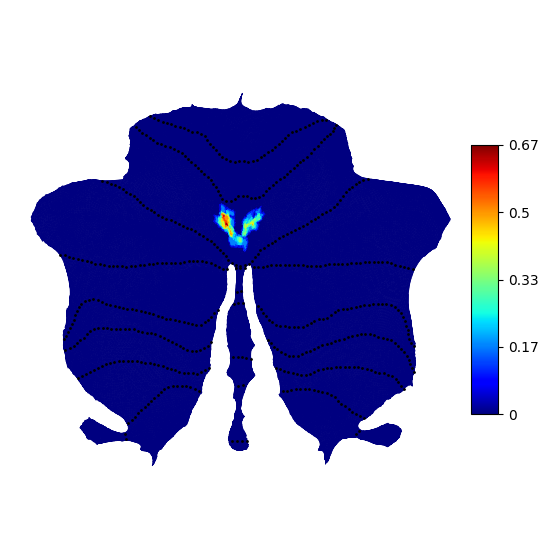

In [7]:
funcdata = flatmap.vol_to_surf(combined_img, space='FSL')
# ax = flatmap.plot()
ax = flatmap.plot(data=funcdata, 
                  # cmap=cmap, 
    new_figure=True, 
    colorbar=True, 
    render='matplotlib',
)

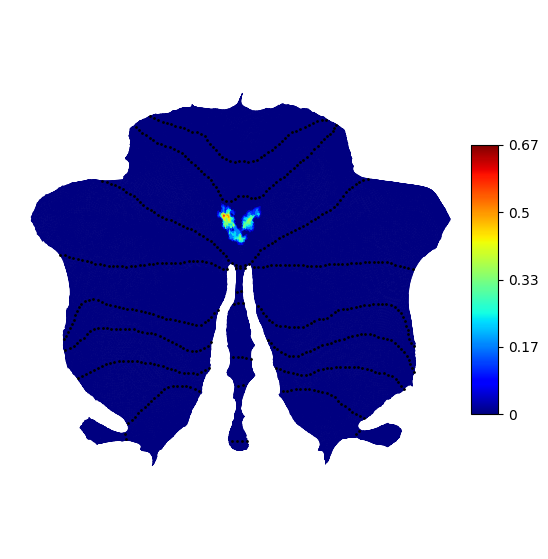

In [8]:
funcdata = flatmap.vol_to_surf(combined_img, space='SUIT')
# ax = flatmap.plot()
ax = flatmap.plot(data=funcdata, 
                  # cmap=cmap, 
    new_figure=True, 
    colorbar=True, 
    render='matplotlib',
)